Run after join_liu_greenness and join_greennessx2

NOTE: PLD has better coverage of small gswl lakes

TODO: 
* more clever filter using convex hull: throw out any mismatch based on strict area criteria, then groupby and flag duplicates as currently written
* Rename cols to reflect source ds

In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
import os
import numpy as np
from shapely.geometry import box

from land_cover.load import plot_dir, loadLiu, loadGlobathy, loadGSWL, loadGreenness, GLAKES_gswl_pth

%load_ext autoreload
%autoreload 2

In [2]:
gswl_og = loadGSWL()
gswl = gswl_og

In [5]:
liu = loadGreenness()

In [6]:
gswl.head()

,id,Zmax,Zmean,q,area,KG,LGM,geometry
0,5784180,230.0,48.30,3.76000,9.832155e+09,26,ice,POINT (35.64414 61.58726)
1,5784179,244.0,86.00,1.84000,1.938403e+10,26,ice,POINT (-77.76209 43.65539)
2,5784178,1632.0,744.45,1.19000,3.210132e+10,23,non_ice,POINT (108.19007 53.53539)
3,5784177,84.0,40.00,1.10000,6.686599e+10,2,non_ice,POINT (32.91142 -1.09922)
4,5784176,1025.0,182.00,4.63187,3.780000e+11,5,non_ice,POINT (50.84252 41.62349)


In [7]:
liu.head()

,OBJECTID,Lake_id,Area_bound,Area_PW,Continent_left,Lat,Lon,GFed_flag,PFed_flag,Endo_flag,...,mann_kendall_trend,trend_significance,b2_mean,b2_stddev,Dmax_est_PAVEW_m,Dmax_use_m,dyn_ratio,depth_ratio,LEV_p13in,geometry
0,3.0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000744,"MULTIPOLYGON (((-92.00626 46.68239, -92.00653 ..."
1,8.0,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,...,no sig. trend,0.95,0.0247,0.0032,393.866667,446.000000,2.353112,0.161883,0.002141,"MULTIPOLYGON (((-119.5765 66.99075, -119.5765 ..."
2,10.0,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,...,no sig. trend,0.27,0.0339,0.0023,7.648739,7.648739,108.838161,0.196111,NaN,"MULTIPOLYGON (((-96.8945 55.40917, -96.89435 5..."
3,10.0,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,...,sig. decreasing,0.03,0.0535,0.0024,12.886283,12.886283,136.047702,0.093122,NaN,"MULTIPOLYGON (((-96.8945 55.40917, -96.89435 5..."
4,10.0,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,...,no sig. trend,0.15,0.0276,0.0017,11.722149,11.722149,125.582494,0.110901,NaN,"MULTIPOLYGON (((-96.8945 55.40917, -96.89435 5..."


In [8]:
# ensure same CRS
if gswl.crs != liu.crs:
    gswl = gswl.to_crs(liu.crs)

# compute area in km^2 from gswl and matching criterion (within 8% of Area_PW)
gswl["area_km2"] = gswl["area"] / 1e6
gswl.drop(columns="area")

# rename namespace vars by replacing columns `old_names` with `new_names`
old_names = gswl.columns.drop("geometry")
new_names = [name + "_gswl" for name in old_names]
gswl = gswl.rename(columns=dict(zip(old_names, new_names)))

# use convex hull for join
# liu["_og_geom"] = liu.geometry
# liu["geometry"] = liu.convex_hull

# spatial join points -> polygons using contains
joined = gpd.sjoin(liu, gswl, how='left', predicate='contains')

In [9]:
grouped = joined.sort_values("Area_bound").groupby("Lake_id")
join_counts = grouped.area_km2_gswl.count()
joined = grouped.last()

In [ ]:
# determine matching lakes
joined["match_gswl"] = np.nan

joined.loc[
    joined["area_km2_gswl"] >= 0,
    "match_gswl",
] = 0


valid = joined['area_km2_gswl'].notna() & (joined['Area_PW'] > 0)
rel_diff = (np.sqrt(joined["area_km2_gswl"]) - np.sqrt(joined["Area_PW"])).abs() / np.sqrt(joined["Area_PW"])
joined.loc[
    valid
    & (rel_diff <= 0.5 )
    # & (joined["Area_bound"] >= joined["area_km2_gswl"])
    & join_counts == 1,
    "match_gswl",
] = 1

print(
    f"Found {len(joined):,} features; liu matches = {joined['match_gswl'].sum():,} / {(~joined.match_gswl.isna()).sum():,}, length of liu: {len(liu):,}"
)

Found 1,878,284 features; liu matches = 1,504,488.0 / 1,618,748, length of liu: 1,885,492


<Axes: ylabel='Frequency'>

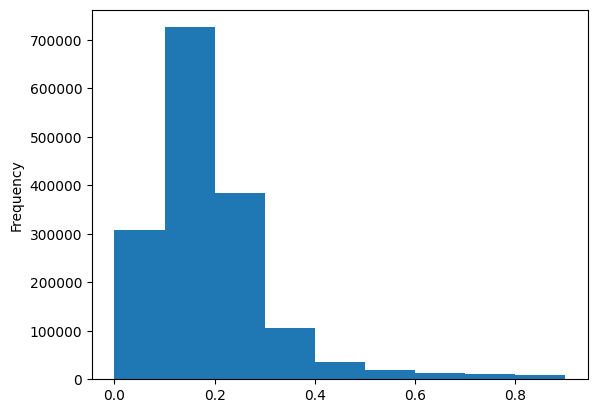

In [11]:
rel_diff.plot.hist(bins=np.arange(0, 1, 0.1))

<Axes: ylabel='Frequency'>

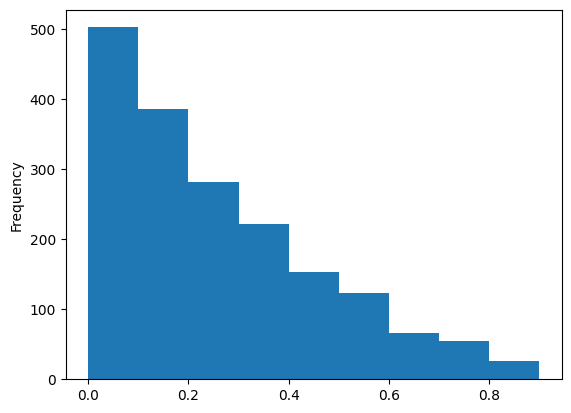

In [12]:
np.log(rel_diff).plot.hist(bins=np.arange(0, 1, 0.1))

Sanity check

<Axes: xlabel='Area_PW', ylabel='area_km2_gswl'>

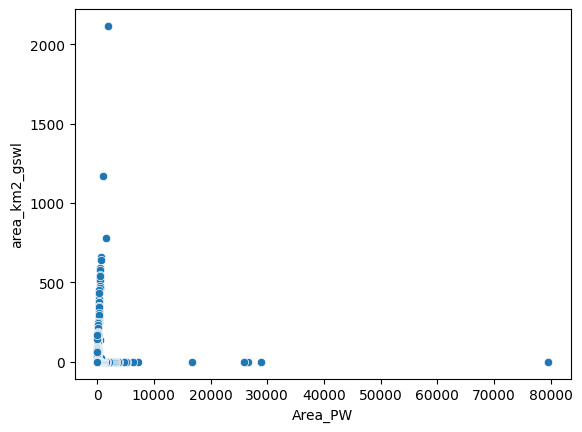

In [13]:
sns.scatterplot(joined, x="Area_PW", y="area_km2_gswl")

In [20]:
joined.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1878284 entries, 3 to 3426388
Data columns (total 71 columns):
 #   Column              Dtype   
---  ------              -----   
 0   OBJECTID            float64 
 1   Area_bound          float64 
 2   Area_PW             float64 
 3   Continent_left      object  
 4   Lat                 float64 
 5   Lon                 float64 
 6   GFed_flag           int64   
 7   PFed_flag           int64   
 8   Endo_flag           int64   
 9   Rser_flag           int64   
 10  Shape_Leng          float64 
 11  Shape_Area          float64 
 12  areaP1              float64 
 13  areaP2              float64 
 14  areaP3              float64 
 15  NDVI8499            float64 
 16  NDVI0010            float64 
 17  NDVI1121            float64 
 18  area_1984_          float64 
 19  area_2000_          float64 
 20  area_2010_          float64 
 21  LEV_p1              float64 
 22  LEV_p2              float64 
 23  LEV_p3              float64 


In [26]:
# convert to pandas nullable integer dtype so values are integers while preserving NA
joined["match_gswl"] = joined["match_gswl"].astype("Int8")

In [ ]:
# reprocess names
# joined = joined.rename(columns={""})

In [ ]:
# overwrite
if GLAKES_gswl_pth.exists():
    GLAKES_gswl_pth.unlink()
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=liu.crs)
joined.to_file(GLAKES_gswl_pth)
# joined.loc[joined.match_gswl==True, :].to_file(GLAKES_gswl_pth)

print(
    f"Wrote {len(joined)} features to {GLAKES_gswl_pth}; matches = {joined['match_gswl'].sum()}"
)

Wrote 1878284 features to /Volumes/metis/Datasets/Liu_aq_veg/figshare/original-private-repo/edk_out/GLAKES_gswl.gpkg; matches = 1504488
